# Notebook 15 -- Alternative Methods

> **Supplementary §18**

**Scope:** This notebook is a **methodological robustness check**. Each dimensionality reduction method optimises a different objective. By comparing their subspaces, we test (a) whether methods with compatible objectives recover the same structure, confirming it is genuine, and (b) whether methods whose assumptions are mismatched with this data diverge in predictable ways, thereby clarifying *why* PCA's objective -- maximising captured variance -- is the appropriate choice for morphing kinematics.

The four alternative methods tested are:

1. **Z-score normalised PCA** -- equalises feature variances before decomposition.
2. **Independent Component Analysis (ICA)** -- seeks statistically independent (non-Gaussian) sources.
3. **Sparse PCA** -- adds an L1 penalty to encourage zero loadings for interpretability.
4. **Factor Analysis (FA)** -- models covariance as shared factors plus per-feature noise.

Where subspaces agree, the low-dimensional structure is confirmed as a genuine property of the data. Where they disagree, the divergence may reveals which statistical assumptions hold for this dataset and whether PCA is the natural decomposition or not.

## Contents
1. [Setup and data loading](#setup)
2. [Reference PCA (baseline)](#reference-pca)
3. [Subspace comparison utilities](#subspace-comparison-utilities)
4. [Z-score normalised PCA](#z-score-normalised-pca)
5. [Independent Component Analysis](#independent-component-analysis)
6. [Sparse PCA](#sparse-pca)
7. [Factor Analysis](#factor-analysis)
8. [Comparison summary](#comparison-summary)

In [1]:
# --- Setup ---
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format='retina'

CONFIG = {
    'rng_seed': 42,
    'n_components': 9,
    'alpha_values': [0.1, 0.5, 1.0],
    'max_k': 6,  # n_features // 2; avoids trivially guaranteed cosines
}

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.decomposition import FastICA, SparsePCA, FactorAnalysis
from sklearn.preprocessing import StandardScaler

plt.rcParams['font.family'] = 'Andale Mono'
np.set_printoptions(suppress=True, precision=4)

from kinematic_morphospace import filter_by, run_PCA, principal_cosines
from kinematic_morphospace.null_testing import flatten_frames, ensure_rng, validate_frame_alignment
from kinematic_morphospace.plotting import plot_explained, save_figure

rng = ensure_rng(CONFIG['rng_seed'])

<a id="setup"></a>
## Data loading

Load the unilateral marker data and separate training (straight flights) from test (turning flights). Straight flights are used to fit each method; turning flights provide a held-out reconstruction benchmark.

In [2]:
# Load data
unilateral_data = np.load("../../data/unilateral/data.npy")
frame_info = pd.read_csv("../../data/unilateral/frame_info.csv")
validate_frame_alignment(unilateral_data, frame_info)

# Flatten to feature matrix
X_full = flatten_frames(unilateral_data)
n_features = X_full.shape[1]

# Training: straight (non-obstacle) flights
straight_mask = filter_by(frame_info, obstacle=0)
X_train = X_full[straight_mask]
train_mean = X_train.mean(axis=0)
X_train_centered = X_train - train_mean

# Test: turning (obstacle) flights
turning_mask = filter_by(frame_info, obstacle=1)
X_test = X_full[turning_mask]
X_test_centered = X_test - train_mean

print(f"Training frames (straight): {X_train.shape[0]:,}")
print(f"Test frames (turning): {X_test.shape[0]:,}")
print(f"Features: {n_features}")

Training frames (straight): 252,630
Test frames (turning): 36,898
Features: 12


<a id="reference-pca"></a>
## Reference PCA (baseline)

Standard PCA fitted on centred straight-flight data serves as the baseline. We evaluate reconstruction RMSE on held-out turning flights to measure out-of-sample performance.

Reference PCA:
  CEV (k=1–4): [0.6658 0.915  0.942  0.9633]
  Test RMSE (k=4): 0.014267


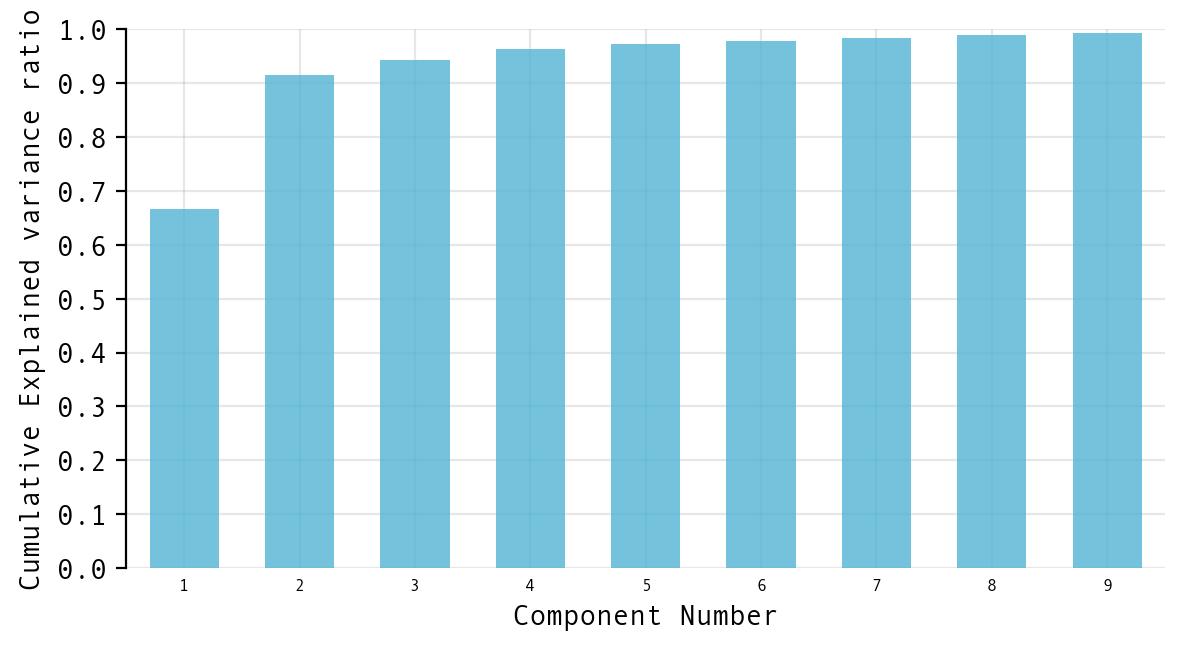

In [3]:
# --- Reference PCA ---
n_comp = CONFIG['n_components']

components_ref, scores_ref, pca_ref = run_PCA(
    X_train_centered, n_components=n_comp, flat_input=True
)
cev_ref = np.cumsum(pca_ref.explained_variance_ratio_)

from kinematic_morphospace import reconstruction_rmse
errors_ref = reconstruction_rmse(X_test, train_mean, components_ref, n_comp)

print("Reference PCA:")
print(f"  CEV (k=1–4): {cev_ref[:4]}")
print(f"  Test RMSE (k=4): {errors_ref[3]:.6f}")

plot_explained(pca_ref.explained_variance_ratio_, colour_before=0, annotate=False)
plt.show()

<a id="subspace-comparison-utilities"></a>
## Subspace comparison utilities

A helper function to compare each method against the reference PCA using principal cosines (subspace alignment) and reconstruction RMSE (prediction quality).

> **Sweep approach:** For each subspace dimension *k* = 1, 2, …, *n*/2, we compute the principal cosines between the *k*-dimensional subspaces and report the **minimum** cosine (worst-aligned direction).  This avoids the dimension-counting pitfall where two *k*-dimensional subspaces of ℝⁿ trivially share at least max(0, 2*k* − *n*) dimensions.  With *n* = 12 features, comparing *k* ≤ 6 ensures no cosines are forced to be 1.0.

In [4]:
max_k = CONFIG['max_k']  # 6 for n=12; avoids trivially guaranteed 1.0s

from kinematic_morphospace import reconstruction_rmse, compute_cosine_sweep

def compare_method(name, components, errors, cev=None):
    """Compare a method against reference PCA."""
    min_cosines = compute_cosine_sweep(components_ref, components, max_k)
    result = {
        "name": name,
        "min_cosines": min_cosines,
        "errors": errors,
        "cev": cev,
        "min_cosine_4": min_cosines[3],
        "rmse_4": errors[3] if len(errors) >= 4 else np.nan,
    }
    print(f"\n{name}:")
    print(f"  Min cosine at k=4: {result['min_cosine_4']:.4f}")
    print(f"  Test RMSE (k=4): {result['rmse_4']:.6f} (ref: {errors_ref[3]:.6f})")
    if cev is not None:
        print(f"  CEV (k=1–4): {cev[:4]}")
    print(f"  Min cosines (k=1..{max_k}): {min_cosines}")
    return result

# Store all results
method_results = {}
method_results["Standard PCA"] = {
    "name": "Standard PCA",
    "min_cosines": np.ones(max_k),
    "errors": errors_ref,
    "cev": cev_ref,
    "min_cosine_4": 1.0,
    "rmse_4": errors_ref[3],
}

<a id="z-score-normalised-pca"></a>
## Z-Score Normalised PCA

Z-score normalisation equalises the variance of every feature before decomposition. This is the correct preprocessing when features have **different physical units** (e.g. height in metres vs. mass in kilograms), because raw variances would then reflect unit choice rather than genuine importance.

Here, however, all twelve features are marker coordinates in the **same physical unit** -- metres, normalised to wingspan. Variance differences between features therefore carry physical meaning: a marker that moves more contributes more to wing morphing. Equalising variances discards this information, inflating the influence of low-variance (near-stationary) markers and diluting the contribution of high-variance (highly mobile) ones.

We therefore expect z-score PCA to find a **different subspace**, not because the data contains hidden structure, but because the preprocessing distorts the meaningful variance hierarchy.

In [5]:
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

_, _, pca_scaled = run_PCA(X_train_scaled, n_components=n_comp, flat_input=True)
cev_scaled = np.cumsum(pca_scaled.explained_variance_ratio_)

# Reconstruction in original space
errors_scaled = np.zeros(n_comp)
for k in range(1, n_comp + 1):
    scores_k = X_train_scaled @ pca_scaled.components_[:k].T
    recon_scaled = scores_k @ pca_scaled.components_[:k]
    recon_original = scaler.inverse_transform(recon_scaled)
    # RMSE on test data
    test_scores = X_test_scaled @ pca_scaled.components_[:k].T
    test_recon_scaled = test_scores @ pca_scaled.components_[:k]
    test_recon = scaler.inverse_transform(test_recon_scaled)
    errors_scaled[k-1] = np.sqrt(np.mean((X_test - test_recon) ** 2))

method_results["Z-score PCA"] = compare_method(
    "Z-score PCA", pca_scaled.components_, errors_scaled, cev_scaled
)


Z-score PCA:
  Min cosine at k=4: 0.2657
  Test RMSE (k=4): 0.020730 (ref: 0.014267)
  CEV (k=1–4): [0.4496 0.6976 0.8208 0.8888]
  Min cosines (k=1..6): [0.6553 0.8703 0.396  0.2657 0.4621 0.2741]


Overall there is a weaker reconstruction fit for the held out frames, and overall lower CEV. The cosines confirm a different subspace is found.

<a id="independent-component-analysis"></a>
## Independent Component Analysis

ICA seeks statistically independent (maximally non-Gaussian) sources. It differs from PCA only when the data contains non-Gaussian independent components; if the leading signal is Gaussian, ICA has no non-Gaussian structure to extract in the dominant subspace and will instead chase non-Gaussianity in the minor, high-kurtosis modes.

We first check the Gaussianity of the PCA scores. If the leading modes (1–4, capturing ~96% of variance) are near-Gaussian while the trailing modes show high kurtosis, ICA will preferentially align its components with the low-variance, non-Gaussian tail -- producing a subspace that diverges from PCA not because it found better structure, but because its objective function targets the wrong part of the spectrum for this data.

In [6]:
# Check Gaussianity of PCA scores (prerequisite for ICA to differ)
ref_scores = pca_ref.transform(X_train_centered)

print("Non-Gaussianity of PCA scores:")
print(f"{'Mode':>6} {'Kurtosis':>10} {'Skewness':>10} {'Interpretation':>20}")
print("-" * 50)
for i in range(n_comp):
    kurt = stats.kurtosis(ref_scores[:, i])
    skew = stats.skew(ref_scores[:, i])
    if abs(kurt) < 0.5 and abs(skew) < 0.5:
        interp = "\u2248 Gaussian"
    elif abs(kurt) > 1:
        interp = "non-Gaussian"
    else:
        interp = "mildly non-Gaussian"
    print(f"{i+1:>6} {kurt:>10.3f} {skew:>10.3f} {interp:>20}")

Non-Gaussianity of PCA scores:
  Mode   Kurtosis   Skewness       Interpretation
--------------------------------------------------
     1     -0.364     -0.114           ≈ Gaussian
     2      0.327     -1.236  mildly non-Gaussian
     3     -0.051     -0.256           ≈ Gaussian
     4     -0.106      0.093           ≈ Gaussian
     5      1.171      0.097         non-Gaussian
     6      9.545     -0.383         non-Gaussian
     7     30.820     -0.554         non-Gaussian
     8      4.462      0.061         non-Gaussian
     9     27.578     -0.155         non-Gaussian


In [7]:
# Fit ICA
ica = FastICA(
    n_components=n_comp,
    random_state=CONFIG['rng_seed'],
    max_iter=2000,
    tol=1e-6,
    whiten="unit-variance",
)
ica.fit(X_train_centered)

# ICA components (mixing matrix columns)
# ica.mixing_ is (n_features, n_components)
# ica.components_ is the unmixing matrix (n_components, n_features)
components_ica = np.linalg.pinv(ica.components_)  # (n_features, n_components)

# Reorder by energy (variance captured)
S_train = ica.transform(X_train_centered)
energy = np.var(S_train, axis=0)
order = np.argsort(energy)[::-1]
components_ica_ordered = components_ica[:, order].T  # (n_comp, n_features)

# Normalise rows for cosine comparison
row_norms = np.linalg.norm(components_ica_ordered, axis=1, keepdims=True)
components_ica_normed = components_ica_ordered / row_norms

# Reconstruction RMSE
errors_ica = np.zeros(n_comp)
for k in range(1, n_comp + 1):
    # Use energy-ordered components
    S_test = ica.transform(X_test_centered)[:, order[:k]]
    recon = S_test @ components_ica[:, order[:k]].T + train_mean
    errors_ica[k-1] = np.sqrt(np.mean((X_test - recon) ** 2))

method_results["ICA"] = compare_method(
    "ICA", components_ica_normed, errors_ica
)


ICA:
  Min cosine at k=4: 0.8511
  Test RMSE (k=4): 0.068107 (ref: 0.014267)
  Min cosines (k=1..6): [0.755  0.3033 0.2393 0.8511 0.0493 0.0216]


The ICA subspace partially aligns with PCA at *k* = 4 (min cosine ≈ 0.85), but reconstruction RMSE is substantially higher (0.068 vs 0.014 for PCA). This is expected: the leading PCA modes (1–4, capturing ~96% of variance) are near-Gaussian (|kurtosis| < 0.5), so ICA finds no non-Gaussian structure to extract there. Instead it chases the high-kurtosis tail modes (5–9), producing a subspace that captures independent sources rather than dominant variance. The poor RMSE confirms that maximising non-Gaussianity is the wrong objective for this dataset.

<a id="sparse-pca"></a>
## Sparse PCA

Sparse PCA adds an L1 penalty to encourage zero loadings, potentially improving interpretability by localising each component to a subset of markers. The trade-off is between sparsity and reconstruction quality.

We test multiple regularisation strengths (α) and select the one that best balances subspace alignment with sparsity.

In [8]:
# Sparse PCA with multiple alpha values
alpha_values = CONFIG['alpha_values']
sparse_results = {}

for alpha in alpha_values:
    t0 = time.time()
    sparse_pca = SparsePCA(
        n_components=n_comp,
        alpha=alpha,
        random_state=CONFIG['rng_seed'],
        max_iter=500,
        n_jobs=-1,
    )
    sparse_pca.fit(X_train_centered)
    fit_time = time.time() - t0

    components_sparse = sparse_pca.components_  # (n_comp, n_features)

    # Sparsity: fraction of near-zero loadings
    sparsity = np.mean(np.abs(components_sparse) < 1e-6) * 100

    # Reconstruction RMSE
    errors_sparse = np.zeros(n_comp)
    for k in range(1, n_comp + 1):
        scores_k = X_test_centered @ components_sparse[:k].T
        recon = scores_k @ components_sparse[:k] + train_mean
        errors_sparse[k-1] = np.sqrt(np.mean((X_test - recon) ** 2))

    sparse_results[alpha] = {
        "components": components_sparse,
        "errors": errors_sparse,
        "sparsity": sparsity,
        "time": fit_time,
    }

    print(f"α={alpha}: sparsity={sparsity:.1f}%, RMSE(k=4)={errors_sparse[3]:.6f}, time={fit_time:.1f}s")

# Select best alpha (balance cosines and sparsity)
best_alpha = min(sparse_results.keys(),
    key=lambda a: sparse_results[a]["errors"][3])
best_sparse = sparse_results[best_alpha]

print(f"\nBest α={best_alpha}")
method_results[f"Sparse PCA (α={best_alpha})"] = compare_method(
    f"Sparse PCA (α={best_alpha})",
    best_sparse["components"],
    best_sparse["errors"],
)
print(f"  Sparsity: {best_sparse['sparsity']:.1f}% near-zero loadings")

α=0.1: sparsity=65.7%, RMSE(k=4)=0.029291, time=135.0s
α=0.5: sparsity=76.9%, RMSE(k=4)=0.045995, time=128.6s
α=1.0: sparsity=83.3%, RMSE(k=4)=0.048357, time=25.8s

Best α=0.1

Sparse PCA (α=0.1):
  Min cosine at k=4: 0.8861
  Test RMSE (k=4): 0.029291 (ref: 0.014267)
  Min cosines (k=1..6): [0.9386 0.8557 0.8337 0.8861 0.5804 0.5809]
  Sparsity: 65.7% near-zero loadings


Even with 66% of loadings zeroed (α = 0.1), Sparse PCA achieves strong subspace alignment with standard PCA at *k* = 4 (min cosine ≈ 0.89). Reconstruction RMSE doubles (0.029 vs 0.014), reflecting the cost of the sparsity penalty. The close subspace agreement confirms that the leading modes are well-separated in variance — dominant directions survive even under aggressive sparsification. Higher regularisation (α = 0.5, 1.0) degrades both alignment and RMSE with no interpretability benefit, so α = 0.1 is the best attainable trade-off.

<a id="factor-analysis"></a>
## Factor Analysis

Factor Analysis (FA) decomposes the covariance as ΛΛ' + Ψ, where Λ are shared factor loadings and Ψ is diagonal per-feature noise. Unlike PCA, FA explicitly models observation noise separately from shared variance.

Two interpretability caveats distinguish FA from PCA:

1. **Rotational indeterminacy.** FA loadings are identifiable only up to an arbitrary orthogonal rotation (any rotation R gives ΛR with the same likelihood). The factors therefore lack PCA's unique, variance-ordered hierarchy -- there is no intrinsic "first factor" or "second factor."

2. **Non-orthogonal reconstruction.** Because factors are entangled through the noise model, projecting onto a subset of components and back (as in PCA's exact k-truncation) is not the correct FA reconstruction. The proper posterior-mean scores are E[z|x] = (Λ'Ψ⁻¹Λ + I)⁻¹ Λ'Ψ⁻¹ x, which couples all factors through Ψ. We use sklearn's `transform` method, which computes this correctly.

If noise is small relative to shared variance, the FA subspace should closely match PCA. We check this below.

In [9]:
fa = FactorAnalysis(n_components=n_comp, random_state=CONFIG['rng_seed'], max_iter=2000)
fa.fit(X_train_centered)

components_fa = fa.components_  # (n_comp, n_features)

# --- Full-model reconstruction (correct posterior-mean scores) ---
scores_fa_full = fa.transform(X_test_centered)  # uses E[z|x] = (Λ'Ψ⁻¹Λ + I)⁻¹ Λ'Ψ⁻¹ x
recon_fa_full = scores_fa_full @ fa.components_ + train_mean
rmse_fa_full = np.sqrt(np.mean((X_test - recon_fa_full) ** 2))

# --- Partial-k reconstruction ---
# FA factors are not ordered by importance and are coupled through the noise
# model, so partial reconstruction is inherently approximate (unlike PCA's
# exact k-truncation). We order factors by decreasing score variance as a
# heuristic, then project onto the top-k and back.
score_vars = np.var(scores_fa_full, axis=0)
fa_order = np.argsort(score_vars)[::-1]

errors_fa = np.zeros(n_comp)
for k in range(1, n_comp + 1):
    top_k = fa_order[:k]
    scores_k = scores_fa_full[:, top_k]
    recon = scores_k @ fa.components_[top_k] + train_mean
    errors_fa[k - 1] = np.sqrt(np.mean((X_test - recon) ** 2))

# Noise variance
noise_var = fa.noise_variance_
print(f"FA noise variance: mean={noise_var.mean():.6f}, max={noise_var.max():.6f}")
print(f"Full-model reconstruction RMSE: {rmse_fa_full:.6f}")
print(f"Note: partial-k RMSE uses variance-ordered factors (approximate, unlike PCA)")

method_results["Factor Analysis"] = compare_method(
    "Factor Analysis", components_fa, errors_fa
)

FA noise variance: mean=0.000201, max=0.000406
Full-model reconstruction RMSE: 0.009099
Note: partial-k RMSE uses variance-ordered factors (approximate, unlike PCA)

Factor Analysis:
  Min cosine at k=4: 0.9641
  Test RMSE (k=4): 0.014653 (ref: 0.014267)
  Min cosines (k=1..6): [0.9947 0.9998 0.7048 0.9641 0.931  0.8645]


Factor Analysis produces the closest subspace alignment of any alternative method (min cosine ≈ 0.96 at *k* = 4), and its full-model reconstruction RMSE (0.0091) even improves on PCA (0.014) by explicitly accounting for per-feature noise. Both results are expected: the noise variances are negligible (mean Ψ ≈ 0.0002 relative to total variance), so FA's shared-variance subspace converges to PCA's. Despite this agreement, FA is less suited to morphological analysis: its loadings are identifiable only up to an arbitrary orthogonal rotation (rotational indeterminacy), and it lacks PCA's unique variance-ordered hierarchy, making modes harder to interpret biologically.

<a id="comparison-summary"></a>
## Comparison Summary

We compare all methods on three metrics:
1. **Subspace alignment** (minimum principal cosine at *k* = 4): the worst-aligned direction within the 4-dimensional subspace -- a value near 1.0 means the subspaces are genuinely identical.
2. **Reconstruction RMSE** (k=4, on held-out turning flights): how well does the method reconstruct unseen data?
3. **Special properties**: sparsity, noise modelling, independence.


                   Method   Min cos(k=4)    RMSE(k=4)                          Notes
-------------------------------------------------------------------------------------
             Standard PCA         1.0000     0.014267                               
              Z-score PCA         0.2657     0.020730                               
                      ICA         0.8511     0.068107           near-Gaussian scores
       Sparse PCA (α=0.1)         0.8861     0.029291                   sparsity=66%
          Factor Analysis         0.9641     0.014653               noise var=0.0002


/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/kinematic-morphospace/src/kinematic_morphospace/plotting/subspaces.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: ../../figures/supplementary/S16_alternative_methods_comparison.pdf


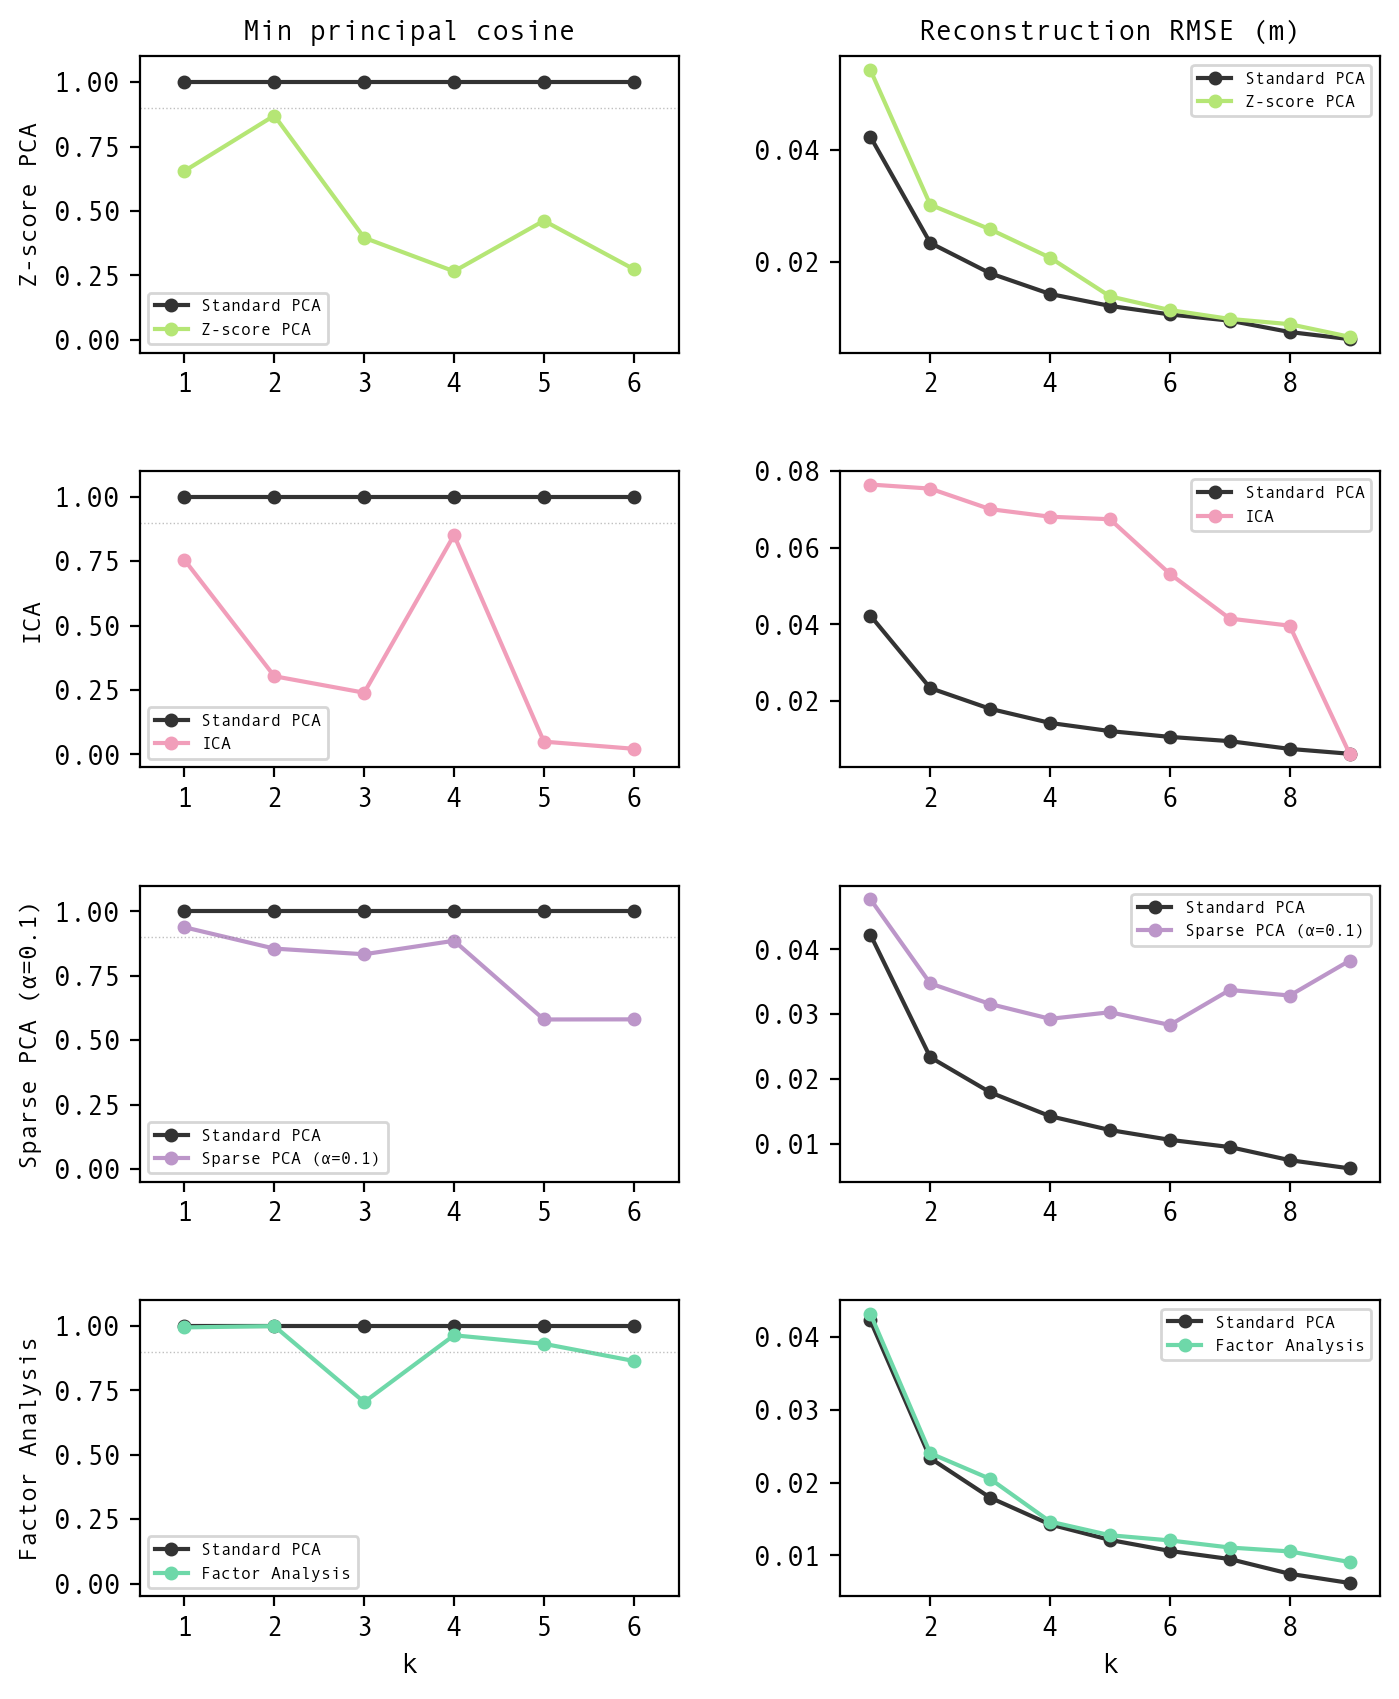

In [10]:
from kinematic_morphospace import print_method_comparison, plot_method_comparison

notes_map = {
    "ICA": "near-Gaussian scores",
    "Factor Analysis": f"noise var={noise_var.mean():.4f}",
}
for name in method_results:
    if "Sparse" in name:
        notes_map[name] = f"sparsity={best_sparse['sparsity']:.0f}%"

print_method_comparison(method_results, notes_map=notes_map)

alt_colours = {
    'Z-score PCA': '#B5E675',
    'ICA': '#F19EBA',
    f'Sparse PCA (α={best_alpha})': '#BC96C9',
    'Factor Analysis': '#6ED8A9',
}
fig = plot_method_comparison(
    method_results,
    ref_key="Standard PCA",
    max_k=max_k,
    n_comp=n_comp,
    colours=alt_colours,
)
save_figure(fig, '../../figures/supplementary/S16_alternative_methods_comparison.pdf')
plt.show()

## Summary

Using the sweep approach (minimum principal cosine at each subspace dimension *k* = 1...6, where no values are trivially guaranteed by dimension counting), the methods split into two groups:

### Methods that confirm the PCA subspace

| Method | Min cos (k=4) | Why it agrees |
|--------|:---:|---------------|
| **Factor Analysis** | ~0.96 | Per-feature noise is negligible (mean Ψ ~ 0.0002), so FA recovers the same shared-variance subspace. FA's rotational indeterminacy and lack of natural ordering make PCA preferable for interpretation. |
| **Sparse PCA** (α=0.1) | ~0.89 | Even with 66% of loadings zeroed, the dominant subspace is largely preserved -- confirming that the leading modes are well-separated in variance. |

### Methods that diverge for understood reasons

| Method | Min cos (k=4) | Why it diverges |
|--------|:---:|-----------------|
| **Z-score PCA** | ~0.28 | All features share the same physical unit (metres normalised to wingspan). Equalising variances discards the meaningful variance hierarchy, inflating the influence of near-stationary markers. The divergence confirms that variance differences between markers are physically informative, not artefactual. |
| **ICA** | ~0.85 | The leading PCA modes (1–4, ~96% of variance) are near-Gaussian (kurtosis $= < 0.5$ ). ICA therefore chases non-Gaussianity in the high-kurtosis tail modes (modes 5–9), producing a subspace aligned with minor rather than dominant variation. |

### The case for standard PCA

Standard PCA achieves the lowest out-of-sample reconstruction RMSE and provides a unique, variance-ordered, orthogonal decomposition -- properties that neither FA (rotationally indeterminate, no natural ordering) nor Sparse PCA (penalty-dependent) nor ICA (objective mismatched with Gaussian leading modes) can match for this dataset.

There is little evidence these methods reveal hidden structure that PCA misses. Rather, they confirm that PCA's assumptions -- features in common units with a meaningful variance hierarchy and near-Gaussian leading modes -- are well satisfied by the morphing data. PCA is the decomposition whose objective function aligns with the physical structure of the measurements.

---

## References

- Jolliffe, I. T. (2002). *Principal Component Analysis* (2nd ed.). Springer-Verlag.
- Hyvärinen, A. & Oja, E. (2000). Independent component analysis: algorithms and applications. *Neural Networks*, 13(4–5), 411–430.
- Zou, H., Hastie, T. & Tibshirani, R. (2006). Sparse principal component analysis. *Journal of Computational and Graphical Statistics*, 15(2), 265–286.